## Titanic Dataset Exploration

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\ENOS\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
# load the data
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Exploratory Data Analysis

In [3]:
train_data.info() #get the general column information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
print(train_data.describe().T) # statistical column information

             count        mean         std   min       25%       50%    75%  \
PassengerId  891.0  446.000000  257.353842  1.00  223.5000  446.0000  668.5   
Survived     891.0    0.383838    0.486592  0.00    0.0000    0.0000    1.0   
Pclass       891.0    2.308642    0.836071  1.00    2.0000    3.0000    3.0   
Age          714.0   29.699118   14.526497  0.42   20.1250   28.0000   38.0   
SibSp        891.0    0.523008    1.102743  0.00    0.0000    0.0000    1.0   
Parch        891.0    0.381594    0.806057  0.00    0.0000    0.0000    0.0   
Fare         891.0   32.204208   49.693429  0.00    7.9104   14.4542   31.0   

                  max  
PassengerId  891.0000  
Survived       1.0000  
Pclass         3.0000  
Age           80.0000  
SibSp          8.0000  
Parch          6.0000  
Fare         512.3292  


#### Null value exploration

In [5]:
# no. of null values in each column
train_data.replace("",np.nan,inplace=True)
train_data.isnull().sum().sort_values(ascending=False)


Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

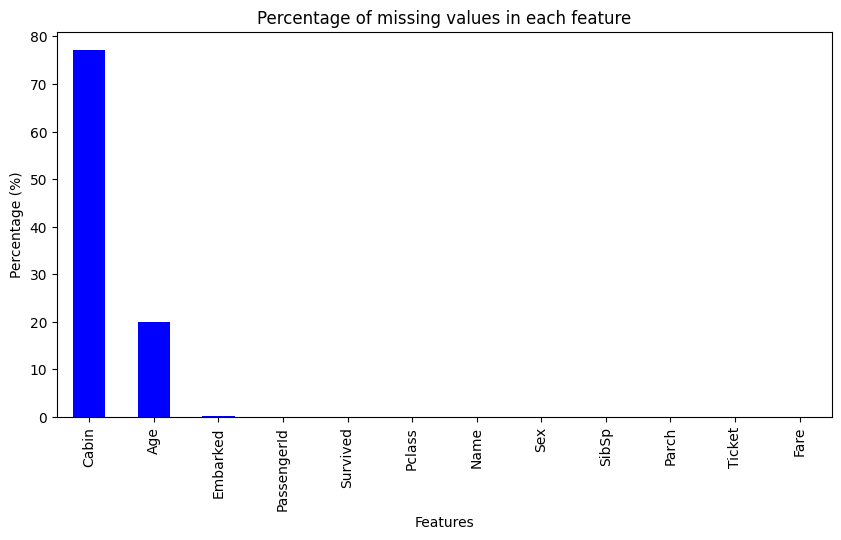

In [6]:
#calculate the percentage of null values
missing_percentage = train_data.isnull().mean()*100
missing_percentage_desc = missing_percentage.sort_values(ascending=False)
missing_percentage_desc

#plot a bar plot of the above
plt.figure(figsize=(10,5))
missing_percentage_desc.plot(kind='bar', color = "blue")
plt.title("Percentage of missing values in each feature")
plt.xlabel("Features")
plt.ylabel("Percentage (%)")
plt.show()


In [7]:
#The cabin feature contains a lot of missing values hence we drop it
train_data = train_data.drop(['Cabin'], axis=1)
test_data = test_data.drop(['Cabin'], axis=1)

train_data.isnull().sum().sort_values(ascending=False)

Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [8]:
#Handling the remaining missing values in the Age and Embarked features

def preprocess_data(df):
    #misssing values in Age are replaced with the column's median value
    df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)
    #missing values in Embarked are replaced with the column's mode value
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


    #cleaning the name column
    df['Surname'] = df['Name'].str.split(", ",expand = True)[0]
    df['FirstName'] = df['Name'].str.extract(r'\. ([A-Za-z]+)')
    df['MaidenName'] = df['Name'].str.extract(r'\((.*?)\)')
    df['MaidenName'] = df['MaidenName'].fillna('None')

    #feature engineering
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = 1
    df['IsAlone'] = np.where(df['FamilySize']>1, 0, 1)
    df['Title'] = df['Name'].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]
    df['Fare per person'] = round(df['Fare'] / df['FamilySize'],2)
    
    #filling in null values
    
    for col_name in df.columns:
        if df[col_name].dtypes == 'object':
            df[col_name] = df[col_name].fillna(df[col_name].mode()[0])
        else:
            df[col_name] = df[col_name].fillna(df[col_name].median())

    def get_age_group(age):
        if age < 13:
            return 'Child'
        elif age < 20:
            return 'Teen'
        elif age < 60:
            return 'Adult'
        else:
            return 'Senior'
    
    df['AgeGroup'] = df['Age'].apply(get_age_group)
        
    return df    


train_data = preprocess_data(train_data)
test_data = preprocess_data(test_data)

In [9]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Surname,FirstName,MaidenName,FamilySize,IsAlone,Title,Fare per person,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,Braund,Owen,None,2,0,Mr,3.62,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,Cumings,John,Florence Briggs Thayer,2,0,Mrs,35.64,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,Heikkinen,Laina,None,1,1,Miss,7.92,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,Futrelle,Jacques,Lily May Peel,2,0,Mrs,26.55,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,Allen,William,None,1,1,Mr,8.05,Adult


In [10]:
#getting identical/duplicate rows
#(In this case, no duplicate rows)
matching_rows = train_data[train_data.duplicated(keep=False)]
matching_rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Surname,FirstName,MaidenName,FamilySize,IsAlone,Title,Fare per person,AgeGroup


In [11]:
#Look for rows that are duplicates and are only differentiated by their values in the survival column.Drop both.
#(Again, no duplicated columns)
columns_to_consider = train_data.columns.difference(['Survived'])
train_data = train_data.drop_duplicates(subset=columns_to_consider,keep=False)
train_data.shape

(891, 19)

In [13]:
train_data = train_data.drop(['Name'], axis=1)
train_data.head(1)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Surname,FirstName,MaidenName,FamilySize,IsAlone,Title,Fare per person,AgeGroup
0,1,0,3,male,22,1,0,A/5 21171,7.25,S,Braund,Owen,None,2,0,Mr,3.62,Adult


#### Categorical encoding

In [14]:
train_data = pd.get_dummies(train_data, columns=['Embarked', 'Title', 'Sex'], drop_first=True)
train_data.head(3)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Surname,FirstName,...,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess,Sex_male
0,1,0,3,22,1,0,A/5 21171,7.2500,Braund,Owen,...,False,False,False,True,False,False,False,False,False,True
1,2,1,1,38,1,0,PC 17599,71.2833,Cumings,John,...,False,False,False,False,True,False,False,False,False,False
2,3,1,3,26,0,0,STON/O2. 3101282,7.9250,Heikkinen,Laina,...,True,False,False,False,False,False,False,False,False,False


In [15]:
train_data.shape

(891, 34)

In [16]:
test_data = pd.get_dummies(test_data, columns=['Embarked', 'Title', 'Sex'], drop_first=True)
test_data.shape

(418, 26)

In [17]:
test_data.shape

(418, 26)

#### Ordinal encoding

In [18]:
age_mapping = {'Child': 0, 'Teen': 1, 'Adult': 2, 'Senior': 3}
train_data['AgeGroup_Encoded'] = train_data['AgeGroup'].map(age_mapping)
test_data['AgeGroup_Encoded'] = test_data['AgeGroup'].map(age_mapping)
train_data.shape,test_data.shape
#N/B: Pclass is already ordinally encoded as it is in number format(1,2,3)

((891, 35), (418, 27))

#### Feature transformation

##### Important for handling outliers and stabilizing variance

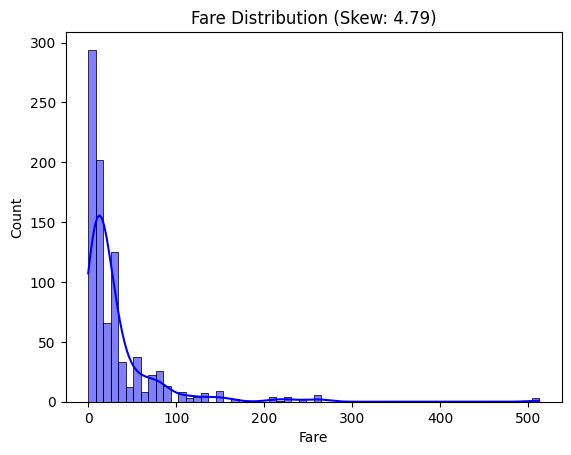

In [20]:
#Check skewness of the fare feature
sns.histplot(train_data['Fare'], color='blue', kde=True)
plt.title(f"Fare Distribution (Skew: {train_data['Fare'].skew():.2f})")
plt.show()

#The fare feature is right skewed(skewness of +4.79) hence needs to be transfomed(using log)

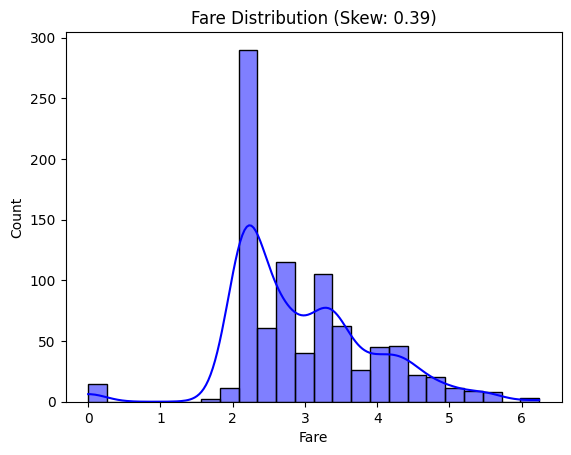

In [21]:
#Log ransform the fare column
train_data['Fare'] = np.log1p(train_data['Fare'])
test_data['Fare'] = np.log1p(test_data['Fare'])

sns.histplot(train_data['Fare'], color='blue', kde=True)
plt.title(f"Fare Distribution (Skew: {train_data['Fare'].skew():.2f})")
plt.show()

#fare is now log transformed and skewness is reduced to 0.39.

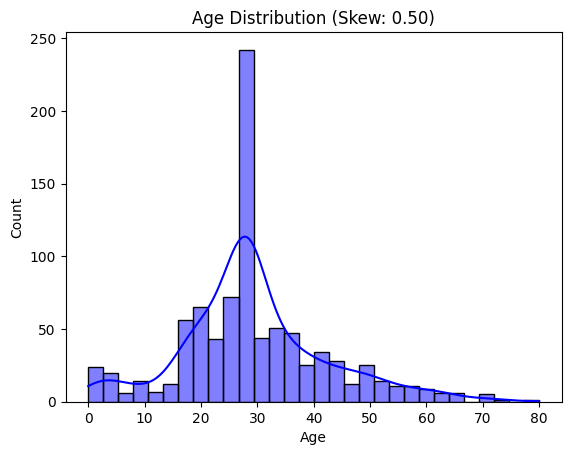

In [22]:
#Check skewness of the Age feature
sns.histplot(train_data['Age'], color='blue', kde=True)
plt.title(f"Age Distribution (Skew: {train_data['Age'].skew():.2f})")
plt.show()

#Age is fairly/normally distributed(skewness of +0.50) hence no transformation needed

#### Standardization/scaling features for distance-based models

##### Ensures our model does not treat bigger values as more important values

In [25]:
# 1. Select the numeric columns you want to scale
num_cols = ['Age', 'Fare', 'FamilySize', 'Pclass']

# 2. Initialize the scaler
scaler = StandardScaler()

# 3. Fit and transform the training data
train_data[num_cols] = scaler.fit_transform(train_data[num_cols])

# 4. Transform the test data (using the same mean/std from train!)
test_data[num_cols] = scaler.transform(test_data[num_cols])

In [34]:
test_data.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Surname,FirstName,...,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess,Sex_male,AgeGroup_Encoded
0,892,0,0.827377,0.357450,0,0,330911,-0.809683,Kelly,James,...,0,0,True,False,False,False,0,0,True,2
1,893,0,0.827377,1.355845,1,0,363272,-0.911513,Wilkes,James,...,0,0,False,True,False,False,0,0,False,2
2,894,0,-0.369365,2.507839,0,0,240276,-0.612461,Myles,Thomas,...,0,0,True,False,False,False,0,0,True,3
3,895,0,0.827377,-0.180147,0,0,315154,-0.716562,Wirz,Albert,...,0,0,True,False,False,False,0,0,True,2
4,896,0,0.827377,-0.564145,1,1,3101298,-0.387631,Hirvonen,Alexander,...,0,0,False,True,False,False,0,0,False,2


In [31]:
train_data.shape, test_data.shape

((891, 35), (418, 35))

Training on 712 rows, Validating on 179 rows.
